In [8]:
import cv2
print(cv2.__version__, hasattr(cv2, "CascadeClassifier"))

4.14.0 True


In [9]:
# 1. imports
%load_ext autoreload

%autoreload 2
import matplotlib.pyplot as plt
from nbutils import (run_live, snapshot, show, detect_preview, summary, plot_session)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(1080, 1920, 3)


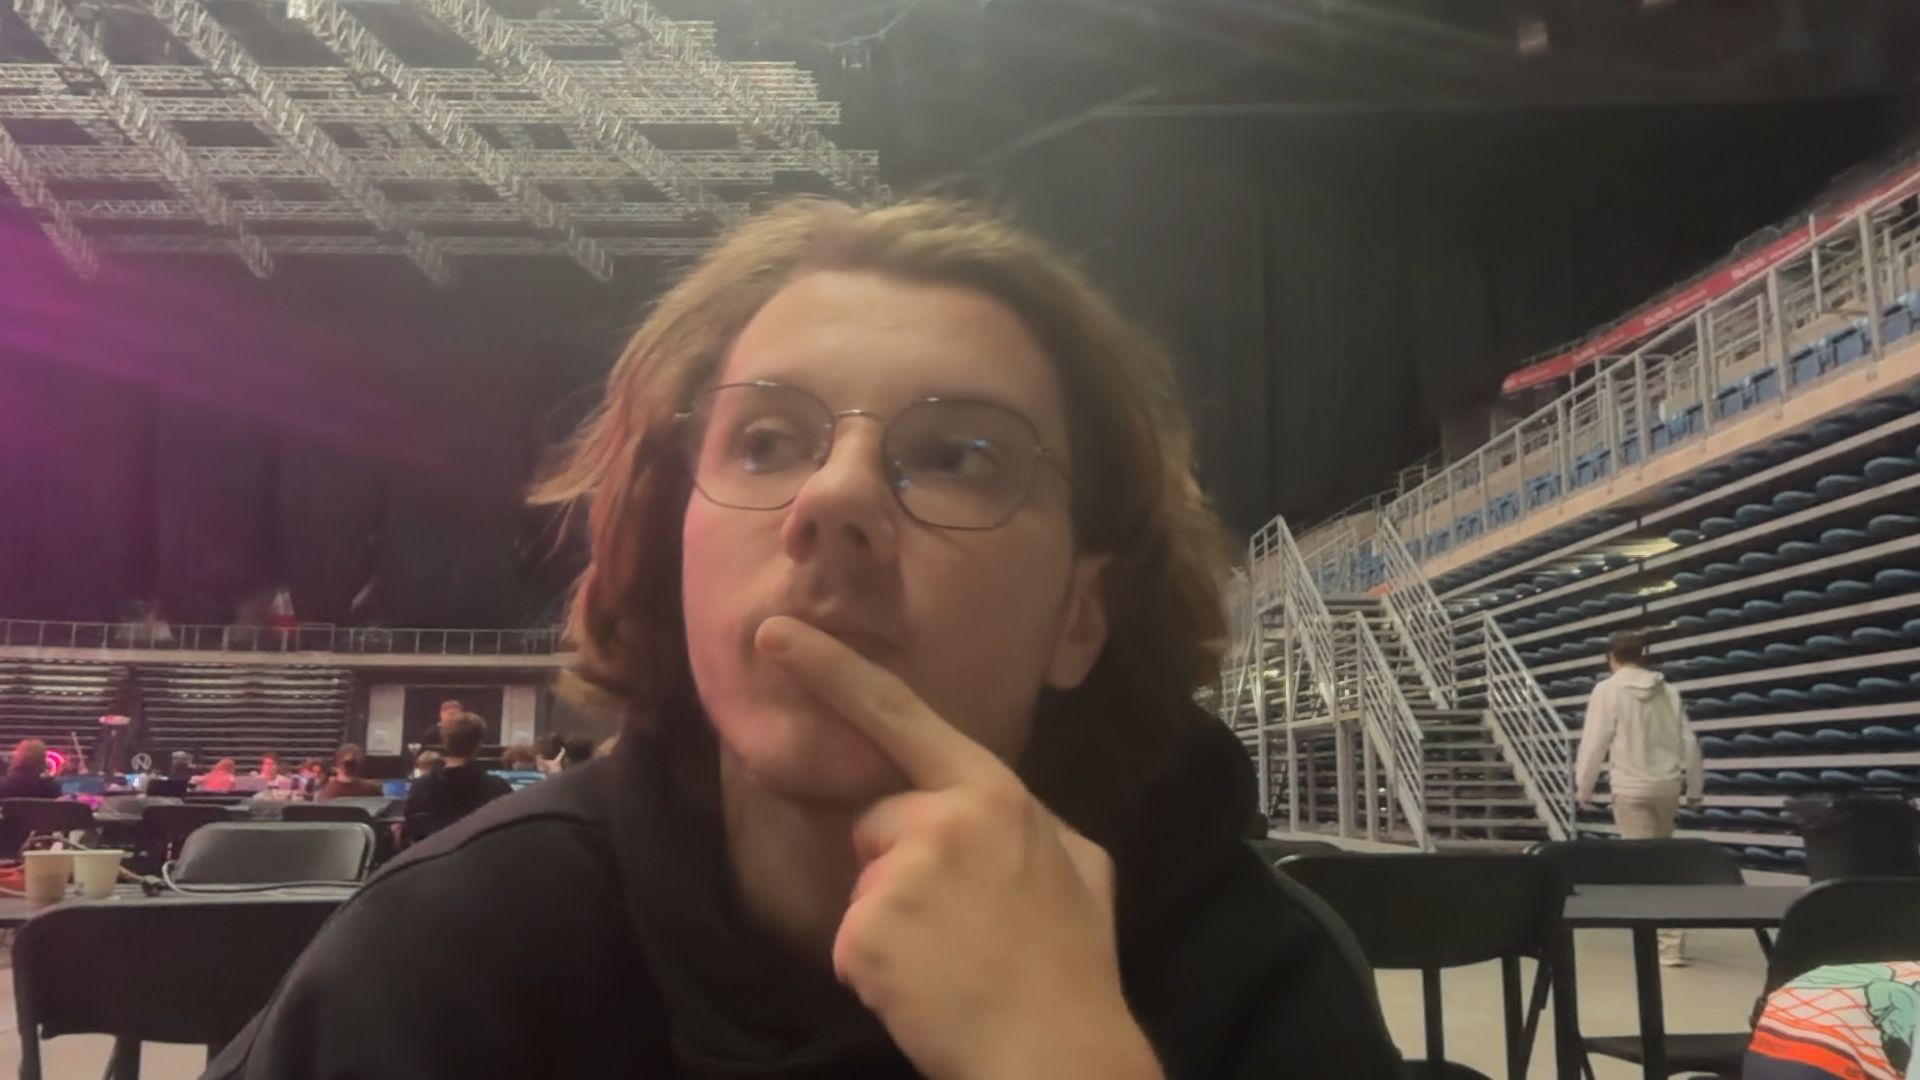

In [10]:
# 2. czy kamera działa?
frame = snapshot(0)
print(frame.shape)
show(frame)

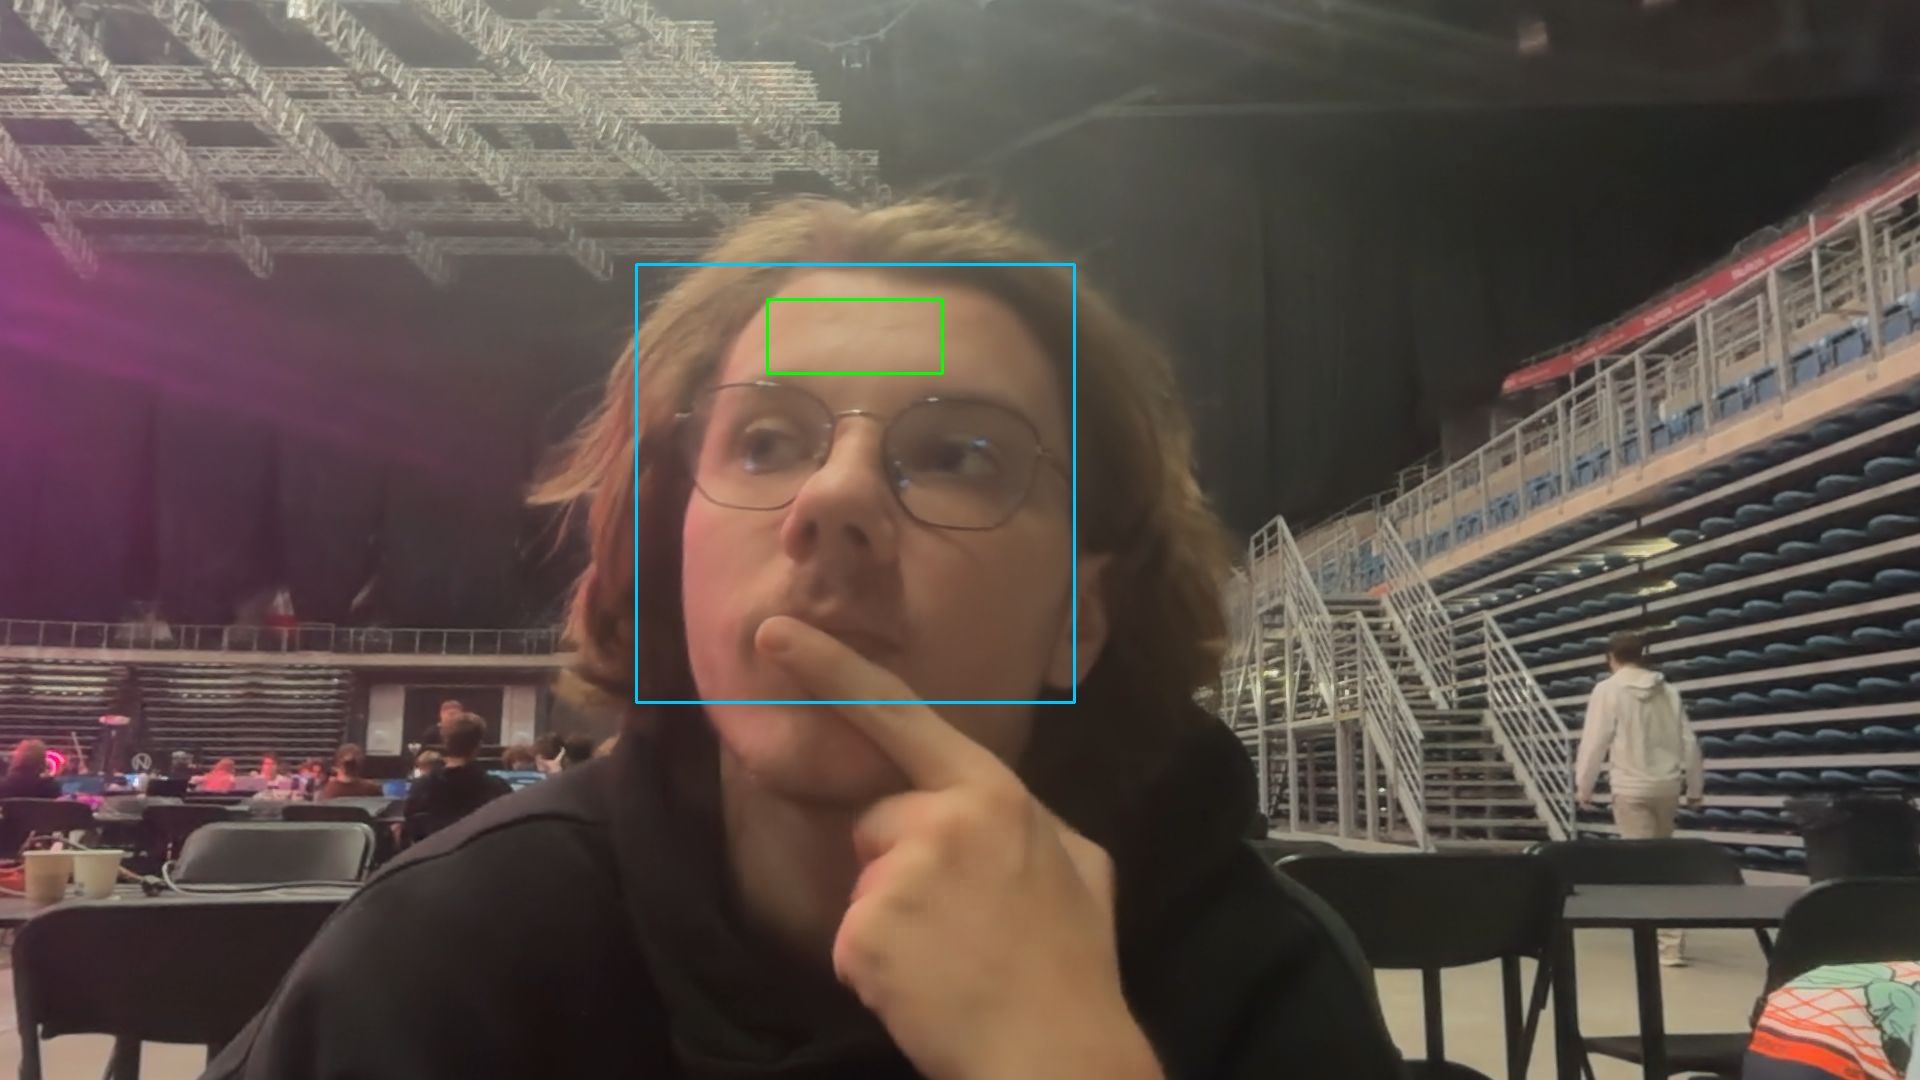

face [x, y, w, h]: [636. 264. 438. 438.]


In [11]:
# 3. czy twarz i czoło są wykryte?
annotated, face = detect_preview(frame)
show(annotated)
print("face [x, y, w, h]:", face)

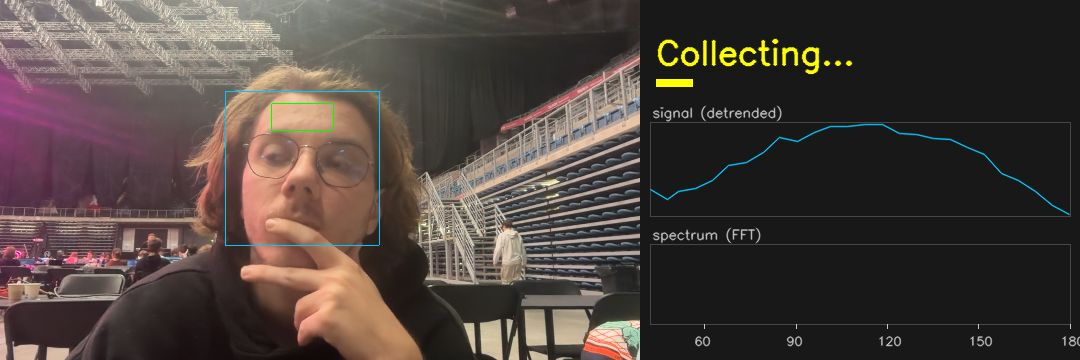

In [12]:
# 4. pomiar na żywo: film po lewej, sygnał i widmo FFT po prawej (30 s)
est = run_live(0, duration=1)

In [13]:
# 5. podsumowanie pomiaru
summary(est)

{'samples': 27, 'duration_s': 0.9, 'sample_rate_hz': 30.4}

In [14]:
# 6. wykresy całej sesji
#plot_session(est)

In [15]:
# 7. te same dane, inne parametry, bez nowego pomiaru
full = est.estimate_full(fmin=0.8, fmax=2.5, channels="rg")
print(f"{full.bpm:.1f} bpm, conf {full.snr:.2f}")
plot_session(est, fmin=0.8, fmax=2.5, channels="rg")

AttributeError: 'NoneType' object has no attribute 'bpm'

In [1]:
import time
from vitallens import VitalLens

# Process live frames
vl = VitalLens(method="vitallens", api_key="ogj5q42KXc4MhqVzVZ1t9aqJQJeQRSHBaBieQ0TK")

with vl.stream() as session:
    # In your capture loop (e.g., OpenCV)
    session.push(frame, timestamp=time.time())
    results = session.get_result(block=False)

NameError: name 'frame' is not defined

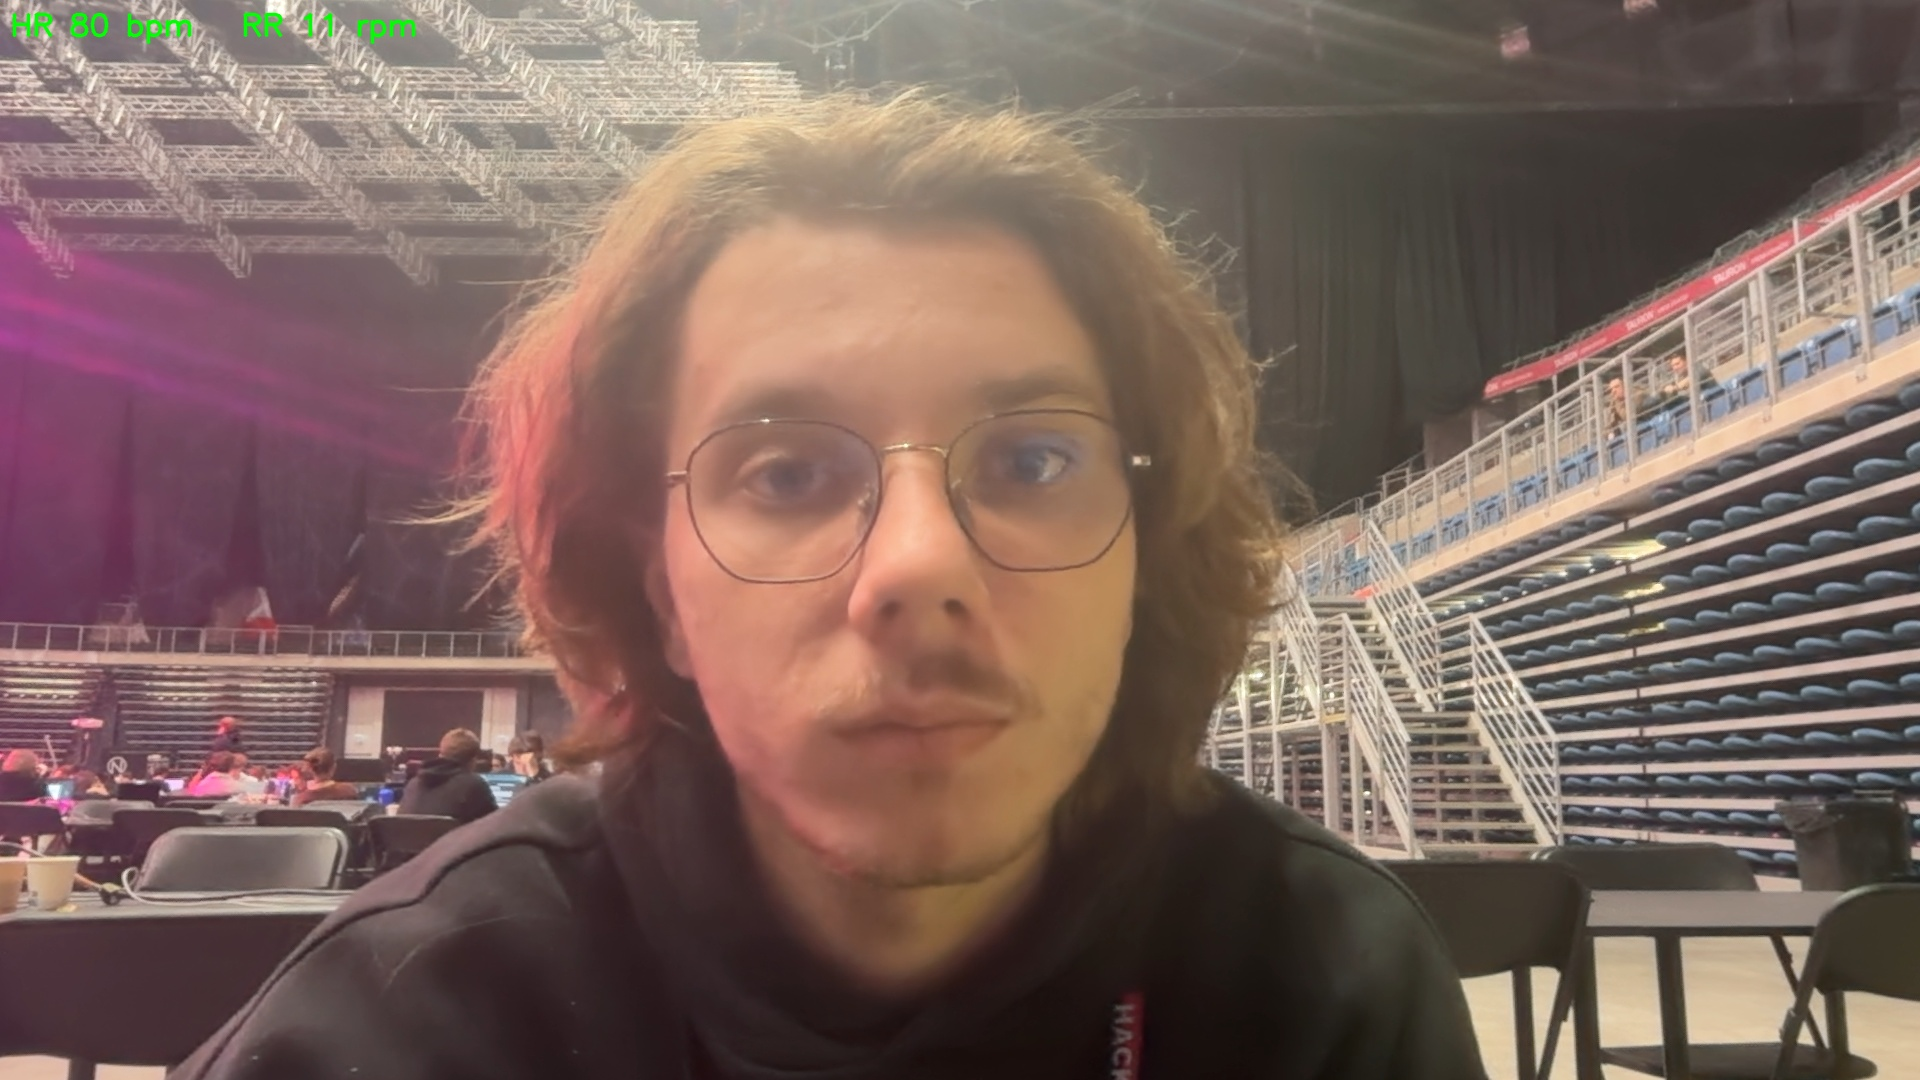

ERROR:root:Error 429: Too Many Requests
ERROR:root:Stream inference error: The quota or rate limit associated with your API Key may have been exceeded. Check your account at https://www.rouast.com/api and consider changing to a different plan.
ERROR:root:Error 429: Too Many Requests
ERROR:root:Stream inference error: The quota or rate limit associated with your API Key may have been exceeded. Check your account at https://www.rouast.com/api and consider changing to a different plan.
ERROR:root:Error 429: Too Many Requests
ERROR:root:Stream inference error: The quota or rate limit associated with your API Key may have been exceeded. Check your account at https://www.rouast.com/api and consider changing to a different plan.


Stopped by user.
results received: 164 | last HR: 79.7773666381836 bpm | last RR: 10.987227439880371 rpm


In [2]:
import getpass
import os
import time

import cv2
from IPython.display import Image as IPyImage, display
from vitallens import VitalLens

DURATION = 40          # seconds; ■ (Interrupt) also stops it cleanly
CAMERA = 0
DISPLAY_FPS = 15

# API key: from the env variable, otherwise asked interactively (never hard-code it in the notebook)
#api_key = os.environ.get("VITALLENS_API_KEY") or getpass.getpass("VitalLens API key: ")
api_key="ogj5q42KXc4MhqVzVZ1t9aqJQJeQRSHBaBieQ0TK"

vl = VitalLens(method="vitallens", api_key=api_key)

cap = cv2.VideoCapture(CAMERA)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open camera {CAMERA}")

history = []                       # (t, heart_rate, respiratory_rate) - available in later cells
hr = rr = None
handle, last_show, t0 = None, 0.0, time.time()

try:
    with vl.stream() as session:
        try:
            while time.time() - t0 < DURATION:
                ok, frame = cap.read()                       # frame = BGR image from OpenCV
                if not ok:
                    break

                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # VitalLens expects RGB
                session.push(rgb, timestamp=time.time())

                results = session.get_result(block=False)      # None until a result is ready
                if results:
                    r0 = results[0] if isinstance(results, (list, tuple)) else results
                    vitals = r0.get("vitals", {})
                    hr = vitals.get("heart_rate", {}).get("value", hr)
                    rr = vitals.get("respiratory_rate", {}).get("value", rr)
                    history.append((time.time() - t0, hr, rr))

                # --- live preview in the notebook (throttled)
                now = time.time()
                if now - last_show >= 1.0 / DISPLAY_FPS:
                    vis = frame.copy()
                    if hr is None:
                        txt, col = "waiting for first result...", (0, 255, 255)
                    else:
                        txt = f"HR {hr:.0f} bpm" + (f"   RR {rr:.0f} rpm" if rr is not None else "")
                        col = (0, 255, 0)
                    cv2.putText(vis, txt, (10, 35), cv2.FONT_HERSHEY_SIMPLEX, 1.0, col, 2, cv2.LINE_AA)
                    img = IPyImage(data=cv2.imencode(".jpg", vis)[1].tobytes(), format="jpeg")
                    if handle is None:
                        handle = display(img, display_id=True)
                    else:
                        handle.update(img)
                    last_show = now
        except KeyboardInterrupt:
            print("Stopped by user.")
finally:
    cap.release()                                              # always free the camera

print(f"results received: {len(history)} | last HR: {hr} bpm | last RR: {rr} rpm")